In [294]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/sample_submission.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv
/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv


# Loading Datasets

In [295]:
train = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/mlp-jan-26-2025-kaggle-assignment-3/test.csv')

In [334]:
train.head()

,id,phrase,feature_1,feature_2,feature_3,sentiment,phrase_length
0,0,It may as well be called `` Jar-Jar Binks : Th...,14.0,5.000000,7.000000,0,58
1,1,You have to see it .,6.0,1.000000,3.334119,2,20
2,2,... either you 're willing to go with this cla...,16.0,0.000000,6.000000,1,82
3,3,Watching Harris ham it up while physically and...,37.0,1.996608,3.000000,1,210
4,4,Pete 's screenplay manages to find that real n...,20.0,1.000000,4.000000,2,113


# Rubrics 1 : Identifying data types of different columns

In [296]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         7000 non-null   int64  
 1   phrase     7000 non-null   object 
 2   feature_1  6088 non-null   float64
 3   feature_2  5896 non-null   float64
 4   feature_3  5938 non-null   float64
 5   sentiment  7000 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 328.3+ KB


In [297]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         1700 non-null   int64  
 1   phrase     1700 non-null   object 
 2   feature_1  1478 non-null   float64
 3   feature_2  1382 non-null   float64
 4   feature_3  1610 non-null   float64
dtypes: float64(3), int64(1), object(1)
memory usage: 66.5+ KB


# Rubrics 2: Present descriptive statistics of numerical columns

In [298]:
train.describe()

,id,feature_1,feature_2,feature_3,sentiment
count,7000.000000,6088.000000,5896.000000,5938.000000,7000.000000
mean,3499.500000,19.025624,1.996608,3.334119,1.041143
std,2020.870275,9.303562,1.634858,2.321154,0.898010
min,0.000000,1.000000,0.000000,0.000000,0.000000
25%,1749.750000,12.000000,1.000000,2.000000,0.000000
50%,3499.500000,18.000000,1.000000,3.000000,1.000000
75%,5249.250000,25.000000,3.000000,4.000000,2.000000
max,6999.000000,52.000000,19.000000,19.000000,2.000000


In [299]:
test.describe()

,id,feature_1,feature_2,feature_3
count,1700.000000,1478.000000,1382.000000,1610.000000
mean,849.500000,19.029093,1.984805,3.449689
std,490.892045,9.203255,1.589858,2.531888
min,0.000000,2.000000,0.000000,0.000000
25%,424.750000,12.000000,1.000000,2.000000
50%,849.500000,18.000000,1.000000,3.000000
75%,1274.250000,25.000000,3.000000,5.000000
max,1699.000000,50.000000,15.000000,23.000000


# Rubrics 3: Identify and handle the missing values

In [300]:
train.isna().sum()

id              0
phrase          0
feature_1     912
feature_2    1104
feature_3    1062
sentiment       0
dtype: int64

In [301]:
test.isna().sum()

id             0
phrase         0
feature_1    222
feature_2    318
feature_3     90
dtype: int64

In [302]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

imputations = SimpleImputer(strategy='mean')
num_cols = ['feature_1', 'feature_2', 'feature_3']

train[num_cols] = imputations.fit_transform(train[num_cols])
test[num_cols] = imputations.transform(test[num_cols])

print(f"Missing values after imputations for train dataset:")
print(train.isna().sum().T)
print()
print(f"Missing values after imputations for test dataset:") 
print(train.isna().sum().T)

Missing values after imputations for train dataset:
id           0
phrase       0
feature_1    0
feature_2    0
feature_3    0
sentiment    0
dtype: int64

Missing values after imputations for test dataset:
id           0
phrase       0
feature_1    0
feature_2    0
feature_3    0
sentiment    0
dtype: int64


# Rubrics 4: Identify and handle duplicates

In [303]:
print("Duplicates in train dataset: ", train.duplicated().sum())
print("Duplicates in test dataset: ", test.duplicated().sum())

Duplicates in train dataset:  0
Duplicates in test dataset:  0


# Rubrics 5: Identify and handle outliers

In [304]:
num_train = train.select_dtypes(include='number')
IQR_train = num_train.quantile(0.75) - num_train.quantile(0.25)

upper_train = num_train.quantile(0.75) + 1.5*IQR_train
lower_train = num_train.quantile(0.25) - 1.5*IQR_train

outliers_train = (num_train < lower_train) | (num_train > upper_train)
outliers_train.sum()

id             0
feature_1    122
feature_2    842
feature_3    331
sentiment      0
dtype: int64

In [305]:
num_test = test.select_dtypes(include='number')
IQR_test = num_test.quantile(0.75) - num_test.quantile(0.25)

upper_test = num_test.quantile(0.75) + 1.5*IQR_test
lower_test = num_test.quantile(0.25) - 1.5*IQR_test

outliers_test = (num_test < lower_test) | (num_test > upper_test)
outliers_test.sum()

id             0
feature_1     24
feature_2    195
feature_3    118
dtype: int64

In [306]:
Q1 = train['feature_1'].quantile(0.25)
Q3 = train['feature_1'].quantile(0.75)

IQR = Q3-Q1

lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR

train = train[(train['feature_1'] >= lower_bound) & (train['feature_1'] <= upper_bound)].reset_index(drop=True)

In [307]:
train[num_cols] = imputations.fit_transform(train[num_cols])
test[num_cols] = imputations.transform(test[num_cols])

# Rubrics 6: Present at least three visualizations and provide insights for the same

In [308]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

In [309]:
train['sentiment'].unique()

array([0, 2, 1])

In [310]:
train['sentiment'].dtype

dtype('int64')

**Visualisation 1 : Sentiment Distribution by Number of Reviews**

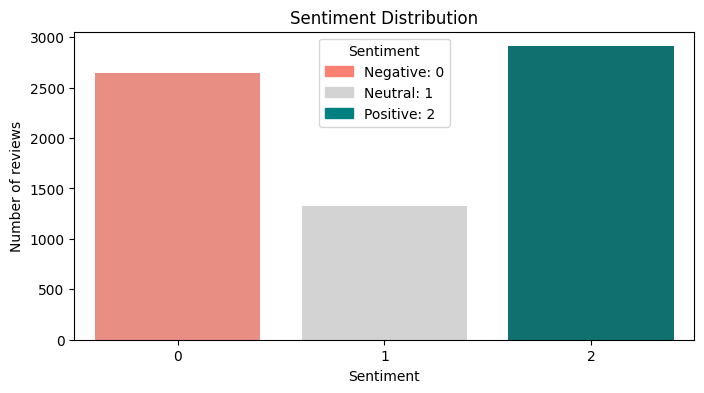

In [311]:
plt.figure(figsize=(8,4))
sns.countplot(x='sentiment', hue='sentiment', data=train, palette={0:'salmon', 1:'lightgray', 2:'teal'})
legend_handles=[Patch(color='salmon', label='Negative: 0'), Patch(color='lightgray', label='Neutral: 1'), Patch(color='teal', label='Positive: 2')]
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of reviews')
plt.legend(handles=legend_handles, title='Sentiment')
plt.show()

**Inference from the plot:** *The distribution from the plot depicts a clear class imbalance in the sentiments of reviews. The positive reviews are the most frequent, followed by the negative reviews and lastly, neutral reviews being significantly lower. This shows that in general people leaving reviews are more critical towards the movie and prefer classifying it into a good and bad one.*



In [312]:
train['phrase_length'] = train['phrase'].astype(str).apply(len)
test['phrase_length'] = test['phrase'].astype(str).apply(len)

**Visualisation 2 : Phrase Length by Sentiment Distribution**

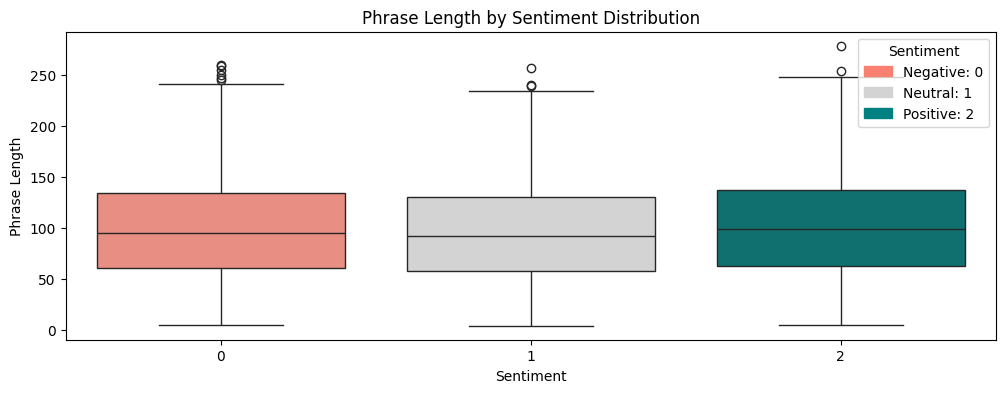

In [313]:
plt.figure(figsize=(12,4))
sns.boxplot(x='sentiment', hue='sentiment', y='phrase_length', data=train, palette={0:'salmon', 1:'lightgray', 2:'teal'})
plt.title('Phrase Length by Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Phrase Length')
plt.legend(handles=legend_handles, title='Sentiment')
plt.show()

**Inference from the Plot:** *The distribution from the plot depicts that the phrase length is fairly similar across all three sentiment categories. Although there is a little variation, however, it can hardly be seen as all sentiment classes share comparable median phrase lengths, and their IQ ranges overlap significantly too. A few longer reviews appear as outliers for all the three sentiment classes, however, we can't see any significant domination by them in the overall pattern.*



**Visualisation 3 : Correlation between Feature and Sentiments**

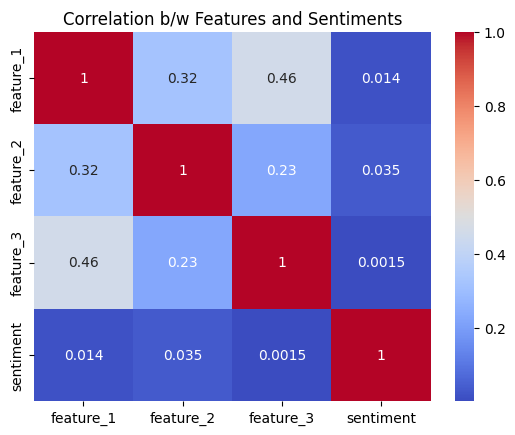

In [314]:
corr = train[['feature_1', 'feature_2', 'feature_3','sentiment']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation b/w Features and Sentiments")
plt.show()

**Inference from the Plot:** 
*The correlation heatmap shows a clear inference on the relation between the features and the sentiments. As we can see all three features have nearly zero correlation with sentiments, it implies that numeric attributes do not explain why a review is positive, negative or neutral. Features do share a slight internal relationship but not with the target column, they might add small auxiliary context but cannot add predictive aid alone.*

*It clears out that the 'phrase' column or the textual data of the column is the primary driver for sentiment learning.*


In [315]:
x=train.drop(columns=['id','sentiment'])
y=train['sentiment']

# Rubrics 7 : Scale Numerical features and Encode Categorical features

In [325]:
from sklearn.preprocessing import MaxAbsScaler, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

num_col = ['feature_1', 'feature_2', 'feature_3', 'phrase_length']
text_col = 'phrase'

ct = ColumnTransformer([
    ('tfidf', TfidfVectorizer(stop_words='english', max_features=25000, ngram_range=(1,2), min_df=2), text_col),
    ('scale', MaxAbsScaler(), num_col),
], remainder='drop')

pipe= Pipeline([
    ('preprocessing', ct),
    ('model', LogisticRegression(max_iter=1000))
])

In [326]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [327]:
pipe.fit(x_train, y_train)
y_pred = pipe.predict(x_val)

# Rubrics 8: Model Building (at least 7)

In [328]:
from sklearn.linear_model import SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC

models={
    "LR": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "SGD": SGDClassifier(class_weight='balanced'),
    "NB": MultinomialNB(),
    "RF" : RandomForestClassifier(n_estimators=100, random_state=42),
    "GB" : GradientBoostingClassifier(),
    "MLP": MLPClassifier(max_iter=300),
    "LinearSVC": LinearSVC(class_weight='balanced')
}

In [329]:
from sklearn.metrics import accuracy_score, f1_score

results=[]

for name, model in models.items():
    pipe=Pipeline([
        ('preprocessing', ct),
        ('model', model)
    ])

    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_val)

    results.append({
        "Model" : name,
        "Accuracy" : accuracy_score(y_val, y_pred),
        "F1_macro" : f1_score(y_val, y_pred, average='macro')
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy,F1_macro
2,NB,0.612645,0.451579
3,RF,0.605378,0.502605
1,SGD,0.595930,0.525350
0,LR,0.593023,0.543036
6,LinearSVC,0.591570,0.528590
5,MLP,0.571221,0.522631
4,GB,0.527616,0.393491


# Rubrics 9: Hyperparameter Tuning on any 3 of the models & Rubrics 10 : Comparison of Model Performances

In [330]:
param_nb={
    'model__alpha': [0.1,0.5,1.0,2.0]
}

param_svc={
    'model__C':[0.1, 0.5, 1, 2, 5]
}

param_lr={
    'model__C':[0.1, 0.5, 1, 2],
    'model__solver':['liblinear', 'lbfgs']
}

In [331]:
from sklearn.model_selection import GridSearchCV

def tune_model(model, param_grid):
    pipe=Pipeline([
        ('preprocessing', ct),
        ('model', model)
    ])
    grid = GridSearchCV(
        pipe,
        param_grid,
        scoring='accuracy',
        cv=3,
        n_jobs=-1
    )
    grid.fit(x_train, y_train)

    print("Best params: ", model, grid.best_params_)
    print("Best CV scores: ", model, grid.best_score_)

    y_pred=grid.predict(x_val)
    print("Validation Accuracy: ", accuracy_score(y_val, y_pred))
    print()
    
    return grid

grid_nb = tune_model(MultinomialNB(), param_nb)
grid_svc = tune_model(LinearSVC(), param_svc)
grid_lr = tune_model(LogisticRegression(max_iter=1000), param_lr)

Best params:  MultinomialNB() {'model__alpha': 0.5}
Best CV scores:  MultinomialNB() 0.603416939294802
Validation Accuracy:  0.6206395348837209

Best params:  LinearSVC() {'model__C': 0.1}
Best CV scores:  LinearSVC() 0.5999636495819702
Validation Accuracy:  0.626453488372093

Best params:  LogisticRegression(max_iter=1000) {'model__C': 1, 'model__solver': 'liblinear'}
Best CV scores:  LogisticRegression(max_iter=1000) 0.6014176663031625
Validation Accuracy:  0.6257267441860465



In [332]:
final_pipe = Pipeline([
    ('preprocessing', ct),
    ('model', LogisticRegression(C=1, solver='liblinear', max_iter=1000))
])

final_pipe.fit(x,y)
test_pred=final_pipe.predict(test)

# Final Submission

In [333]:
submission=pd.DataFrame({
    'id':test['id'],
    'sentiment': test_pred
})
submission.to_csv('submission.csv', index=False)
submission

,id,sentiment
0,0,0
1,1,2
2,2,0
3,3,2
4,4,0
...,...,...
1695,1695,2
1696,1696,2
1697,1697,0
1698,1698,0
